# Matplotlib 折线图、散点图、柱状图速查教程

## 0. 准备与通用设置

- 推荐使用面向对象接口：`fig, ax = plt.subplots()`
- 常用步骤：准备数据 → 创建图形与坐标轴 → 绘制 → 标注 → 布局与保存

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. 折线图（Line Plot）

**用途**：展示连续变量随自变量的变化趋势。
**要点**：

## Fig,Axes=plt.subplots(figsize=(6, 4), layout='constrained')

`figsize`：图尺寸（单位英寸，宽 × 高）。**常用**。

`layout`：布局算法。常用 `'constrained'` 自动避免遮挡；`'tight'` 紧凑布局。二选一即可。**常用**。

# `Axes.plot` 说明

## 行为

在坐标轴上按顺序连接点，绘制折线。
 数据形式：

- `plot(y)` 等价 `plot(range(len(y)), y)`
- `plot(x, y)`
- 可一次传入多组：`plot(x1, y1, fmt1, x2, y2, fmt2, ...)`
   返回：`list[Line2D]`（每条线一个对象）。

## 参数与常用性

### 数据与格式

- `*args`：`(x, y[, fmt]) ...` 或 `(y[, fmt]) ...`。**常用**
- `fmt`：格式速记，如 `'ro--'` = 红色圆点虚线。包含顺序不限：颜色、标记、线型。**按需**

### 线与标记样式（高频）

- `color` / `c`：颜色，如 `'C0'`、`'#1f77b4'`。**常用**
- `linestyle` / `ls`：`'-'` `'--'` `'-.'` `':'` 或空串去线。**常用**
- `linewidth` / `lw`：线宽（points）。**常用**
- `marker`：标记形状，如 `'o'` `'^'` `'s'` `'.'`。**常用**
- `markersize` / `ms`：标记尺寸（points）。**常用**
- `alpha`：透明度 `0~1`。**常用**
- `label`：图例文本（配合 `ax.legend()`）。**常用**

多序列（两种写法等价）：

```python
# 多次调用
ax.plot(x, y1, label='A', lw=2)
ax.plot(x, y2, label='B', ls='--')

# 一次性
ax.plot(x, y1, 'C0-', x, y2, 'C1--')
ax.legend()
```

# `Axes.scatter`

## 行为

在同一坐标轴上绘制**不连线**的点集。点的**位置**由 `x, y` 给出；**大小**由 `s` 控制（单位：点的平方，points²）；**颜色**由 `c` 或统一的单色控制。`c` 为数值序列时可配合 `cmap/norm` 做颜色映射，并可加 `colorbar`。

## 常用函数签名（简化）

```python
ax.scatter(x, y, s=None, c=None, marker=None, cmap=None, norm=None,
           vmin=None, vmax=None, alpha=None, linewidths=None, edgecolors=None,
           label=None, plotnonfinite=False, data=None, **kwargs)
```

## 参数与用法

### 必要/高频（常用）

- `x`, `y`：点坐标。等长数组或序列。
- `s`：点面积（points²）。可标量或序列（逐点大小）。常用。
  - 说明：`s=None` 时使用 rcParams 的默认大小（与 `lines.markersize` 相关）。
- `c`：颜色。可取单色（如 `'C0'`, `'#RRGGBB'`）或数值序列（用于映射）。常用。
  - 若为数值序列，常配合 `cmap`, `norm`, `vmin/vmax`。
- `marker`：点形状（如 `'o'`, `'^'`, `'s'`, `'.'`）。默认 `'o'`。常用。
- `alpha`：透明度 `0~1`。常用。
- `label`：图例文本。常用（配合 `ax.legend()`）。

## 典型用法

单色 + 基本标注：

```python
ax.scatter(x, y, s=36, c='C0', alpha=0.8, label='samples')
ax.legend()
```

数值着色 + 尺寸编码 + 颜色条：

```python
sc = ax.scatter(x, y, c=value, s=size, cmap='viridis', alpha=0.7, edgecolors='none')
fig.colorbar(sc, ax=ax, label='value')
```

性能与可读性提示：

- 海量点优先 `rasterized=True` 或减小 `s`，必要时采样或用 `hexbin/hist2d`。
- 标注少量重点：配合 `ax.annotate` 或二次调用 `scatter` 提高 `zorder`。

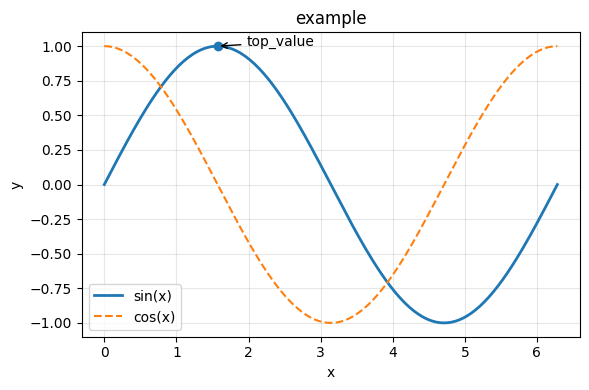

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 数据
x = np.linspace(0, 2*np.pi, 200)#用于在给定区间内生成等间距数值序列。
y1 = np.sin(x)
y2 = np.cos(x)

# 画布
fig, ax = plt.subplots(figsize=(6, 4))

# 绘制
ax.plot(x, y1, label='sin(x)', linewidth=2)
ax.plot(x, y2, label='cos(x)', linestyle='--')
ax.legend()#显示图例

# 标注
ax.set_title('example')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)


# 重点标注一个点
x0 = np.pi/2
y0 = np.sin(x0)
ax.scatter([x0], [y0], zorder=3)
ax.annotate('top_value', xy=(x0, y0), xytext=(x0+0.4, y0),
            arrowprops=dict(arrowstyle='->'))

fig.tight_layout()
plt.show()

## 2. 散点图（Scatter Plot）

**用途**：展示点的分布、相关性；可用颜色或大小编码第三变量。

/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_815219/178174274.py:27: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAP

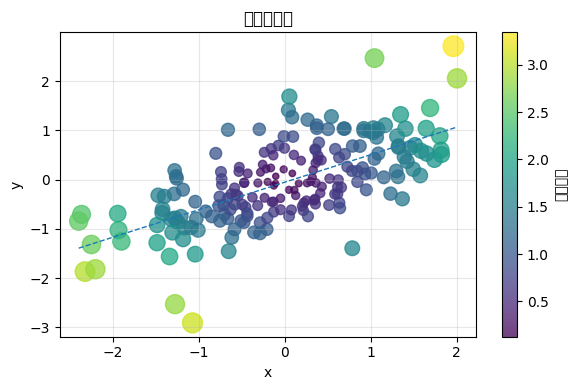

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)#创建独立的随机数发生器（Generator，默认 PCG64）。用于可复现实验
n = 200
x = rng.normal(loc=0, scale=1.0, size=n)
y = 0.6*x + rng.normal(scale=0.6, size=n)
val = np.hypot(x, y)        # 返回到原点的距离
size = (val - val.min())/(np.ptp(val)+1e-9) * 200 + 20  # 点大小，ptp:max - min

fig, ax = plt.subplots(figsize=(6, 4))

sc = ax.scatter(x, y, c=val, s=size, cmap='viridis', alpha=0.75)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('embedding')

ax.set_title('散点图示例')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)

# 简单拟合线
k, b = np.polyfit(x, y, deg=1)
xx = np.linspace(x.min(), x.max(), 100)
ax.plot(xx, k*xx + b, linestyle='--', linewidth=1)

fig.tight_layout()
plt.show()

## 3. 柱状图（Bar Chart）

**用途**：比较类别的数值；可扩展为分组柱状图。
 **要点**：`ax.bar(x, height, width)`；分组用“位置偏移”。

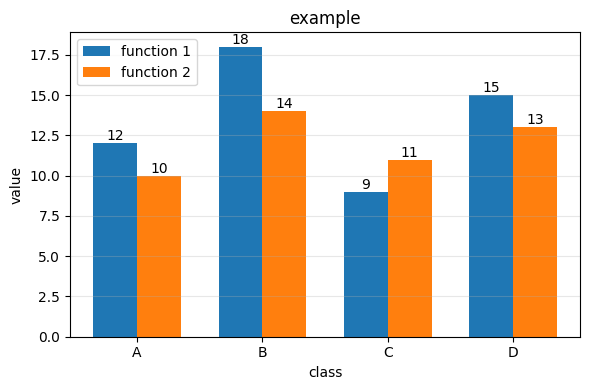

In [1]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['A', 'B', 'C', 'D']
val1   = np.array([12, 18, 9, 15])
val2   = np.array([10, 14, 11, 13])

x = np.arange(len(labels))# x作为每组柱子的中间
w = 0.35  # 柱宽

fig, ax = plt.subplots(figsize=(6, 4))

# 分组柱
bars1 = ax.bar(x - w/2, val1, width=w, label='function 1')
bars2 = ax.bar(x + w/2, val2, width=w, label='function 2') 
ax.legend()#显示图例

ax.set_title('example')
ax.set_xlabel('class')
ax.set_ylabel('value')
ax.set_xticks(x, labels) #设置刻度

ax.grid(axis='y', alpha=0.3)

# 在柱顶显示数值（Matplotlib>=3.4 提供 bar_label）

for b in bars1:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.0f}',
            ha='center', va='bottom')
for b in bars2:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.0f}',
            ha='center', va='bottom')

fig.tight_layout()
plt.show()